# 03 · MLP Character-Level Language Model

Following Bengio et al. (2003): character embeddings → hidden layer → softmax, with mini-batch training, cross-entropy loss and a learning-rate search.

**What I learned:** embeddings, mini-batches, cross-entropy, finding a good learning rate, and train/dev/test splits.

*Dataset: `data/names.txt`. Following Karpathy's Zero to Hero series.*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/llm-from-scratch/blob/main/03-mlp-language-model/03_mlp_character_lm.ipynb)

In [ ]:
# Setup: download the dataset if it is not already present (works on Colab and locally)
import os, urllib.request
os.makedirs('../data', exist_ok=True)
if not os.path.exists('../data/names.txt'):
    urllib.request.urlretrieve('https://raw.githubusercontent.com/karpathy/makemore/master/names.txt', '../data/names.txt')

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
words = open('../data/names.txt','r').read().splitlines()

In [ ]:
len(words)

32033

In [ ]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [ ]:
block_size = 3 # context length: how many characters do we take to predict next one?
x,y = [],[]
for w in words:
  print(w)
  context = [0] * block_size
  for ch in w+'.':
    ix = stoi[ch]
    x.append(context)
    y.append(ix)
    print(''.join(itos[i] for i in context),'---->',itos[ix])
    context = context[1:]+[ix]

x = torch.tensor(x)
y = torch.tensor(y)



Streaming output truncated to the last 5000 lines.
michail
... ----> m
..m ----> i
.mi ----> c
mic ----> h
ich ----> a
cha ----> i
hai ----> l
ail ----> .
michale
... ----> m
..m ----> i
.mi ----> c
mic ----> h
ich ----> a
cha ----> l
hal ----> e
ale ----> .
mihail
... ----> m
..m ----> i
.mi ----> h
mih ----> a
iha ----> i
hai ----> l
ail ----> .
miken
... ----> m
..m ----> i
.mi ----> k
mik ----> e
ike ----> n
ken ----> .
mikyng
... ----> m
..m ----> i
.mi ----> k
mik ----> y
iky ----> n
kyn ----> g
yng ----> .
mila
... ----> m
..m ----> i
.mi ----> l
mil ----> a
ila ----> .
moaaz
... ----> m
..m ----> o
.mo ----> a
moa ----> a
oaa ----> z
aaz ----> .
moaz
... ----> m
..m ----> o
.mo ----> a
moa ----> z
oaz ----> .
moeez
... ----> m
..m ----> o
.mo ----> e
moe ----> e
oee ----> z
eez ----> .
mohamadou
... ----> m
..m ----> o
.mo ----> h
moh ----> a
oha ----> m
ham ----> a
ama ----> d
mad ----> o
ado ----> u
dou ----> .
mohammadomar
... ----> m
..m ----> o
.mo ----> h
moh ----> a
oha 

In [ ]:
x

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        ...,
        [26, 26, 25],
        [26, 25, 26],
        [25, 26, 24]])

In [ ]:
y.shape

torch.Size([228146])

In [ ]:
c = torch.randn(27,2)

In [ ]:
c

tensor([[ 0.5667, -0.0681],
        [-0.2259,  0.5400],
        [-0.9025, -0.8324],
        [ 0.1232, -0.3606],
        [ 1.9319, -0.0031],
        [ 1.0533, -1.5988],
        [-1.2554, -0.6903],
        [-0.6920,  0.4048],
        [ 0.3742, -1.2375],
        [ 0.0217,  0.0664],
        [ 1.1800,  1.2875],
        [-1.0207, -0.0913],
        [ 0.1211,  1.3063],
        [ 0.1615,  1.3134],
        [-0.5281, -0.2212],
        [ 0.9350, -0.3727],
        [ 0.1117, -0.7991],
        [ 0.3657, -0.6374],
        [-1.9059,  0.2119],
        [-2.0516,  1.1930],
        [ 1.3442, -1.7914],
        [-2.3790, -1.0043],
        [ 0.4705,  0.7197],
        [ 1.0838, -0.6093],
        [ 0.1105, -0.6395],
        [-1.4963, -1.3271],
        [ 0.1180,  0.0522]])

In [ ]:
t = F.one_hot(torch.tensor(5),num_classes = 27).float()

In [ ]:
c.shape

torch.Size([27, 2])

In [ ]:
x.shape

torch.Size([228146, 3])

In [ ]:
x[0]

tensor([0, 0, 0])

# Here we are converting a inputs into embeddings
## 2 dimension embedding
## if a char = '.' -> 0 ->[-0.2134,0123]

In [ ]:
emb = c[x]
emb1 = emb[0]
emb = c[x]

In [ ]:
emb1

tensor([[ 0.5667, -0.0681],
        [ 0.5667, -0.0681],
        [ 0.5667, -0.0681]])

In [ ]:
w1 = torch.randn(6,100)
b1 = torch.randn(100)

In [ ]:
emb1[:,:]

tensor([[ 0.5667, -0.0681],
        [ 0.5667, -0.0681],
        [ 0.5667, -0.0681]])

In [ ]:
emb.shape

torch.Size([228146, 3, 2])

In [ ]:
emb1

tensor([[ 0.5667, -0.0681],
        [ 0.5667, -0.0681],
        [ 0.5667, -0.0681]])

In [ ]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1).shape

torch.Size([228146, 6])

In [ ]:
emb.shape

torch.Size([228146, 3, 2])

In [ ]:
torch.cat(torch.unbind(emb,1),1).shape

torch.Size([228146, 6])

In [ ]:
emb.view(-1,6)

tensor([[ 0.5667, -0.0681,  0.5667, -0.0681,  0.5667, -0.0681],
        [ 0.5667, -0.0681,  0.5667, -0.0681,  1.0533, -1.5988],
        [ 0.5667, -0.0681,  1.0533, -1.5988,  0.1615,  1.3134],
        ...,
        [ 0.1180,  0.0522,  0.1180,  0.0522, -1.4963, -1.3271],
        [ 0.1180,  0.0522, -1.4963, -1.3271,  0.1180,  0.0522],
        [-1.4963, -1.3271,  0.1180,  0.0522,  0.1105, -0.6395]])

In [ ]:
g = torch.Generator().manual_seed(2147483647)

In [ ]:
w1 = torch.randn(6,100,generator=g)
b1 = torch.randn(100,generator=g)
h = torch.tanh(emb.view(-1,6) @ w1 + b1)
w2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27,generator=g)

logits = h @ w2 + b2
counts =  logits.exp()
probs = counts / counts.sum(1,keepdims = True)

# Fixed: changed torch.arange(32) to torch.arange(y.shape[0]) to match the dataset size
loss = -probs[torch.arange(y.shape[0]),y].log().mean()

loss

tensor(17.6395)

#Intro to cross entropy

In [ ]:
g = torch.Generator().manual_seed(2147483647)
w1 = torch.randn(6,100,generator=g)
b1 = torch.randn(100,generator=g)
w2 = torch.randn((100,27),generator=g)
b2 = torch.randn(27,generator=g)

h = torch.tanh(emb.view(-1,6) @ w1 + b1)
logits = h @ w2 + b2

# manual
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
loss_manual = -probs[torch.arange(y.shape[0]), y].log().mean()

# built-in, on the SAME logits
loss_builtin = F.cross_entropy(logits, y)

print(loss_manual, loss_builtin)



tensor(15.7831) tensor(15.7831)


#Parameter initialize and calculation of parameters

In [ ]:
parameters = [c,w1,w2,b1,b2]

for p in parameters:
  p.requires_grad = True

sum(p.nelement() for p in parameters)

3481

#Train Neural net

In [ ]:
for i in range(10):


  emb = c[x]
  #forword
  h = torch.tanh(emb.view(-1,6) @ w1 + b1)
  logits = h @ w2 + b2
  loss = F.cross_entropy(logits, y) #loss
  print(loss.item())

  #backprop
  for p in parameters:
    p.grad = None
  loss.backward()


  #update
  for p in parameters:
    p.data += -0.1 * p.grad


15.783061027526855
14.633258819580078
13.792044639587402
12.696593284606934
11.956422805786133
11.381303787231445
10.83922290802002
10.395580291748047
10.004698753356934
9.66157341003418


#Batch (mini_batch)

## why ?
### -> to decrease loss much efficiently
### -> for quicker computation



In [ ]:
x.shape[0]

228146

In [ ]:
for i in range(100):

  #mini batch construction
  xi = torch.randint(0,x.shape[0],(32,))
  emb = c[x[xi]]

  #forword
  h = torch.tanh(emb.view(-1,6) @ w1 + b1)
  logits = h @ w2 + b2
  loss = F.cross_entropy(logits, y[xi]) #loss
  print(loss.item())

  #backprop
  for p in parameters:
    p.grad = None
  loss.backward()


  #update
  for p in parameters:
    p.data += -0.001 * p.grad


11.638422966003418
9.246990203857422
9.968605995178223
7.3320698738098145
8.266529083251953
9.561418533325195
8.293024063110352
7.845005989074707
8.506807327270508
9.299744606018066
8.652628898620605
7.978853225708008
8.495321273803711
9.680624008178711
8.472631454467773
8.687544822692871
8.08769416809082
8.616585731506348
9.608119010925293
8.758514404296875
10.176396369934082
7.6661810874938965
8.047141075134277
10.211079597473145
9.65156078338623
10.228992462158203
9.761537551879883
8.220586776733398
9.296945571899414
7.7878313064575195
10.541705131530762
9.954512596130371
9.873409271240234
6.519359111785889
7.886099338531494
10.028694152832031
9.393689155578613
9.896857261657715
8.243875503540039
8.331734657287598
9.622038841247559
7.468344211578369
12.731208801269531
7.681554317474365
9.287206649780273
9.316922187805176
10.112541198730469
8.022115707397461
9.693364143371582
8.935407638549805
10.407441139221191
9.426741600036621
8.811841011047363
8.438458442687988
6.940110683441162


# How to find a good learning rate ?


In [ ]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre

In [ ]:
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [ ]:
lri = []
lossi = []
for i in range(1000):

  #mini batch construction
  xi = torch.randint(0,x.shape[0],(32,))
  emb = c[x[xi]]

  #forword
  h = torch.tanh(emb.view(-1,6) @ w1 + b1)
  logits = h @ w2 + b2
  loss = F.cross_entropy(logits, y[xi]) #loss
  print(loss.item())

  #backprop
  for p in parameters:
    p.grad = None
  loss.backward()


  #update
  lr = lrs[i]
  for p in parameters:
    p.data += -lr * p.grad

  #track

  lri.append(lrs[i])
  lossi.append(loss.item())


8.804510116577148
7.968286991119385
9.415140151977539
8.539819717407227
8.930051803588867
8.860219955444336
8.886245727539062
8.758909225463867
6.855250358581543
8.734977722167969
7.557361125946045
9.39709186553955
8.904807090759277
9.555147171020508
8.291586875915527
8.249009132385254
10.53069019317627
8.063899040222168
6.6568217277526855
7.594098091125488
10.361678123474121
8.484609603881836
7.677256107330322
11.307086944580078
9.311210632324219
9.56753921508789
8.355992317199707
6.902478218078613
6.2040114402771
9.065984725952148
8.227944374084473
8.892319679260254
7.138478755950928
6.929720401763916
9.150875091552734
8.086851119995117
8.317036628723145
7.536109924316406
7.38351583480835
9.393108367919922
9.145662307739258
9.476592063903809
8.000475883483887
8.206494331359863
7.189357280731201
7.729964733123779
7.4422287940979
11.0299654006958
8.98578929901123
10.023829460144043
5.847084999084473
10.287097930908203
9.450987815856934
7.3573174476623535
8.204939842224121
6.88686275482

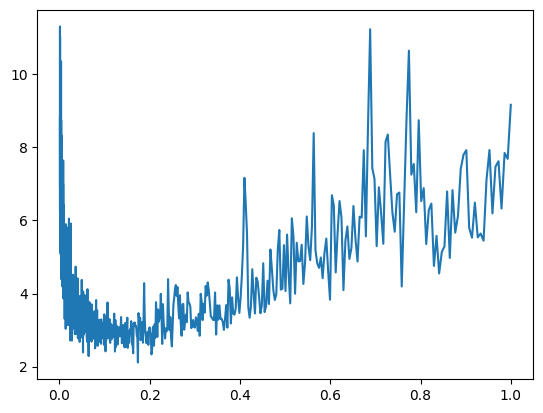

In [ ]:
plt.plot(lri,lossi)